In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df1 = pd.read_csv(r"C:\Users\dell\Downloads\archive\Toddler Autism dataset July 2018.csv")

pd.set_option('display.max_columns', None)

df1

,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1049,1050,0,0,0,0,0,0,0,0,0,1,24,1,f,White European,no,yes,family member,No
1050,1051,0,0,1,1,1,0,1,0,1,0,12,5,m,black,yes,no,family member,Yes
1051,1052,1,0,1,1,1,1,1,1,1,1,18,9,m,middle eastern,yes,no,family member,Yes
1052,1053,1,0,0,0,0,0,0,1,0,1,19,3,m,White European,no,yes,family member,No


In [44]:
df2 = pd.read_csv(r"C:\Users\dell\Downloads\archive\Autism_Screening_Data_Combined.csv")

df2

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jauundice,Family_ASD,Class
0,1,1,0,1,0,0,1,1,0,0,15,m,no,no,NO
1,0,1,1,1,0,1,1,0,1,0,15,m,no,no,NO
2,1,1,1,0,1,1,1,1,1,1,15,f,no,yes,YES
3,1,1,1,1,1,1,1,1,0,0,16,f,no,no,YES
4,1,1,1,1,1,1,1,1,1,1,15,f,no,no,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6070,0,0,0,0,0,0,0,0,0,1,2,f,no,yes,NO
6071,0,0,1,1,1,0,1,0,1,0,1,m,yes,no,NO
6072,1,0,1,1,1,1,1,1,1,1,2,m,yes,no,NO
6073,1,0,0,0,0,0,0,1,0,1,2,m,no,yes,NO


In [45]:
print(df1.shape, df2.shape)
print(df1.columns.equals(df2.columns))

(1054, 19) (6075, 15)
False


In [46]:
print(df1.columns)
print("\n ------------------ ")
print(df2.columns)


Index(['Case_No', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10',
       'Age_Mons', 'Qchat-10-Score', 'Sex', 'Ethnicity', 'Jaundice',
       'Family_mem_with_ASD', 'Who completed the test', 'Class/ASD Traits '],
      dtype='object')

 ------------------ 
Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age',
       'Sex', 'Jauundice', 'Family_ASD', 'Class'],
      dtype='object')


Class/ASD Traits          1.000000
Qchat-10-Score            0.810423
A9                        0.577336
A6                        0.569424
A5                        0.563297
A7                        0.563177
A4                        0.505204
A1                        0.503810
A2                        0.463467
A8                        0.427155
A3                        0.409701
A10                       0.179833
Sex                       0.117664
Case_No                   0.079966
Jaundice                  0.074060
Age_Mons                  0.066831
Who completed the test   -0.010993
Family_mem_with_ASD      -0.013503
Ethnicity                -0.146357
Name: Class/ASD Traits , dtype: float64

 ------------------------


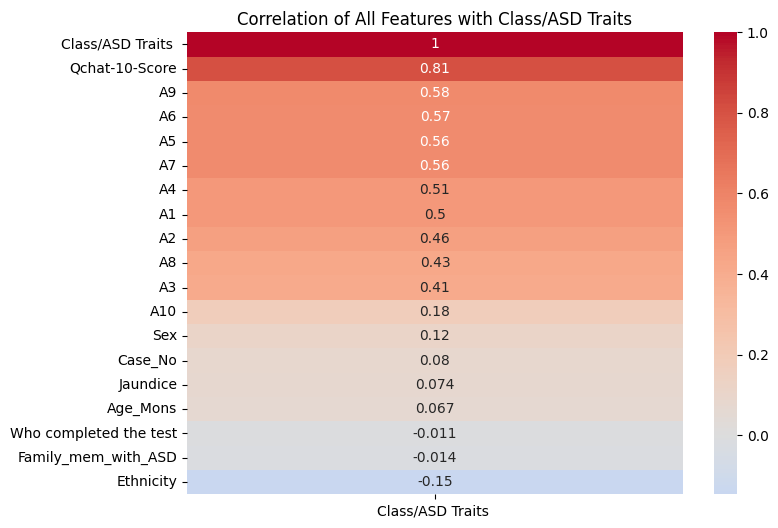

In [47]:
df_encoded = df1.copy()

## Convert categorical columns to numeric using label encoding
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# compute coorelation with target
correlations = df_encoded.corr(numeric_only=True)['Class/ASD Traits '].sort_values(ascending=False)

print(correlations)

print("\n ------------------------")

plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(numeric_only=True)[['Class/ASD Traits ']].sort_values(by='Class/ASD Traits ', ascending=False), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation of All Features with Class/ASD Traits")
plt.show()


features_to_keep = [
    'Qchat-10-Score', 'A1', 'A2', 'A3', 'A4', 'A5',
    'A6', 'A7', 'A8', 'A9', 'A10', 'Sex', 'Jaundice', 'Family_mem_with_ASD'
]


Adding Sex, Jaundice, and Family_mem_with_ASD might capture biological or family history factors — even if weakly correlated, they can help nonlinear models

In [48]:
cleaned_df1 = df1.drop(columns=['Case_No', 'Ethnicity', 'Who completed the test' ])
cleaned_df1.head()


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Jaundice,Family_mem_with_ASD,Class/ASD Traits
0,0,0,0,0,0,0,1,1,0,1,28,3,f,yes,no,No
1,1,1,0,0,0,1,1,0,0,0,36,4,m,yes,no,Yes
2,1,0,0,0,0,0,1,1,0,1,36,4,m,yes,no,Yes
3,1,1,1,1,1,1,1,1,1,1,24,10,m,no,no,Yes
4,1,1,0,1,1,1,1,1,1,1,20,9,f,no,yes,Yes


In [49]:
print('\n ----------------')
print(cleaned_df1.columns)


 ----------------
Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons',
       'Qchat-10-Score', 'Sex', 'Jaundice', 'Family_mem_with_ASD',
       'Class/ASD Traits '],
      dtype='object')


In [50]:
#rename some cols
cleaned_df1.rename(columns={'Age_Mons': 'Age', 'Qchat-10-Score': 'Qchat-Score', 'Class/ASD Traits ': 'Class'}, inplace=True)
cleaned_df1.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Qchat-Score,Sex,Jaundice,Family_mem_with_ASD,Class
0,0,0,0,0,0,0,1,1,0,1,28,3,f,yes,no,No
1,1,1,0,0,0,1,1,0,0,0,36,4,m,yes,no,Yes
2,1,0,0,0,0,0,1,1,0,1,36,4,m,yes,no,Yes
3,1,1,1,1,1,1,1,1,1,1,24,10,m,no,no,Yes
4,1,1,0,1,1,1,1,1,1,1,20,9,f,no,yes,Yes


df1 → shape (1054, 16)

df2 → shape (6075, 15)

df2 has the same 15 columns as df1 except that df1 has one extra column.

create the extra col in the df 2 and make as Nan than concat df's

In [51]:
df2.rename(columns={'Jauundice': 'Jaundice', 'Family_ASD': 'Family_mem_with_ASD'}, inplace=True)
df2.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_mem_with_ASD,Class
0,1,1,0,1,0,0,1,1,0,0,15,m,no,no,NO
1,0,1,1,1,0,1,1,0,1,0,15,m,no,no,NO
2,1,1,1,0,1,1,1,1,1,1,15,f,no,yes,YES
3,1,1,1,1,1,1,1,1,0,0,16,f,no,no,YES
4,1,1,1,1,1,1,1,1,1,1,15,f,no,no,YES


In [52]:
# confirm exactly which column is missing:

set(cleaned_df1.columns) - set(df2.columns)

{'Qchat-Score'}

In [53]:
#create the extra col in the df2 with default value like Nan
df2['Qchat-Score'] = pd.NA

In [54]:
set(cleaned_df1.columns) - set(df2.columns)


set()

In [55]:
print(cleaned_df1.shape, df2.shape)
print(cleaned_df1.columns.equals(df2.columns))

(1054, 16) (6075, 16)
False


In [56]:
print(cleaned_df1.columns)
print('\n -------------------- ')
print(df2.columns)

Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age',
       'Qchat-Score', 'Sex', 'Jaundice', 'Family_mem_with_ASD', 'Class'],
      dtype='object')

 -------------------- 
Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age',
       'Sex', 'Jaundice', 'Family_mem_with_ASD', 'Class', 'Qchat-Score'],
      dtype='object')


Even though both cleaned_df1 and df2 have the same 16 column names, their order is different.

➡️ The difference is column order —
Qchat-Score appears earlier in cleaned_df1, but last in df2.

Because .equals() checks both:

Column names, and

Column order

so --> reorder df2’s columns to match cleaned_df1 before concatenating:

In [57]:
cleaned_df2 = df2[cleaned_df1.columns]

print(cleaned_df2.columns.equals(cleaned_df1.columns))

True


In [58]:
combined_df = pd.concat([cleaned_df1, cleaned_df2], ignore_index=True)
print(combined_df.shape)

(7129, 16)


In [59]:
combined_df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Qchat-Score,Sex,Jaundice,Family_mem_with_ASD,Class
0,0,0,0,0,0,0,1,1,0,1,28,3,f,yes,no,No
1,1,1,0,0,0,1,1,0,0,0,36,4,m,yes,no,Yes
2,1,0,0,0,0,0,1,1,0,1,36,4,m,yes,no,Yes
3,1,1,1,1,1,1,1,1,1,1,24,10,m,no,no,Yes
4,1,1,0,1,1,1,1,1,1,1,20,9,f,no,yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7124,0,0,0,0,0,0,0,0,0,1,2,<NA>,f,no,yes,NO
7125,0,0,1,1,1,0,1,0,1,0,1,<NA>,m,yes,no,NO
7126,1,0,1,1,1,1,1,1,1,1,2,<NA>,m,yes,no,NO
7127,1,0,0,0,0,0,0,1,0,1,2,<NA>,m,no,yes,NO


In [60]:
combined_df.info

<bound method DataFrame.info of       A1  A2  A3  A4  A5  A6  A7  A8  A9  A10  Age Qchat-Score Sex Jaundice  \
0      0   0   0   0   0   0   1   1   0    1   28           3   f      yes   
1      1   1   0   0   0   1   1   0   0    0   36           4   m      yes   
2      1   0   0   0   0   0   1   1   0    1   36           4   m      yes   
3      1   1   1   1   1   1   1   1   1    1   24          10   m       no   
4      1   1   0   1   1   1   1   1   1    1   20           9   f       no   
...   ..  ..  ..  ..  ..  ..  ..  ..  ..  ...  ...         ...  ..      ...   
7124   0   0   0   0   0   0   0   0   0    1    2        <NA>   f       no   
7125   0   0   1   1   1   0   1   0   1    0    1        <NA>   m      yes   
7126   1   0   1   1   1   1   1   1   1    1    2        <NA>   m      yes   
7127   1   0   0   0   0   0   0   1   0    1    2        <NA>   m       no   
7128   1   1   0   0   1   1   0   1   1    0    2        <NA>   m      yes   

     Family_mem_wit

In [61]:
combined_df.isna().sum()

A1                        0
A2                        0
A3                        0
A4                        0
A5                        0
A6                        0
A7                        0
A8                        0
A9                        0
A10                       0
Age                       0
Qchat-Score            6075
Sex                       0
Jaundice                  0
Family_mem_with_ASD       0
Class                     0
dtype: int64

**Data cleanning Step**

In [62]:
combined_df['Sex'] = combined_df['Sex'].str.strip().str.lower()
combined_df['Jaundice'] = combined_df['Jaundice'].str.strip().str.lower()
combined_df['Family_mem_with_ASD'] = combined_df['Family_mem_with_ASD'].str.strip().str.lower()
combined_df['Class'] = combined_df['Class'].str.strip().str.lower()

combined_df['Class'] = combined_df['Class'].replace({'yes': 'ASD', 'no': 'No ASD'})

In [63]:
print(combined_df['Age'].value_counts())

print('\n -------------------------------------------------------')

print(combined_df['Age'].min())
print(combined_df['Age'].mean())
print(combined_df['Age'].max())


Age
3     547
36    399
2     347
4     323
20    257
     ... 
78      1
73      1
80      1
70      1
68      1
Name: count, Length: 76, dtype: int64

 -------------------------------------------------------
1
21.025108710899143
80


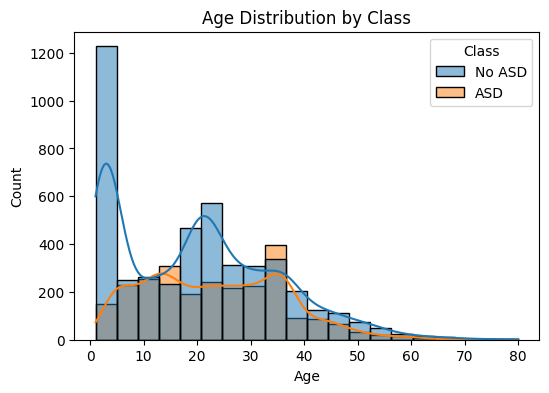

In [64]:
plt.figure(figsize=(6,4))
sns.histplot(data=combined_df, x='Age', hue='Class', bins=20, kde=True)
plt.title('Age Distribution by Class')
plt.show()

Look at the tallest blue bar, which is around age 20 **Month**.

-The bar for "No ASD" reaches just above 1200 on the Count axis. This means there are over 1200 people without ASD who are around 20 Month old in this dataset.

-The orange bar for "ASD" at the same age is much shorter, reaching just above 200. This means there are just over 200 people with ASD who are around 20 Month old.

In [65]:
print(combined_df['Qchat-Score'].value_counts())
print(f"type : ", combined_df['Qchat-Score'].dtype)

print('\n -------------------------------------------')

print(combined_df['Qchat-Score'].min())
print(combined_df['Qchat-Score'].mean())
print(combined_df['Qchat-Score'].max())

Qchat-Score
7     135
5     120
4     110
8      97
3      96
6      96
9      95
2      88
1      88
10     75
0      54
Name: count, dtype: int64
type :  object

 -------------------------------------------
0
5.212523719165086
10


C:\Users\dell\AppData\Local\Temp\ipykernel_22280\3536925578.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_df, x='Class', y='Qchat-Score', palette='Set2')


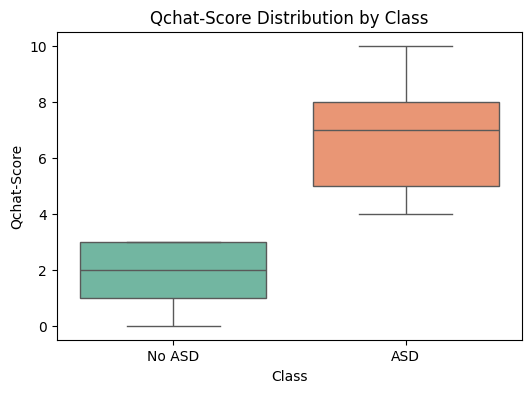

In [66]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=combined_df, x='Class', y='Qchat-Score', palette='Set2')
plt.title("Qchat-Score Distribution by Class")
plt.show()

In [67]:
#access Class when Score = 5

print(combined_df.loc[combined_df['Qchat-Score'] < 3, 'Class' ].value_counts())

print('\n ------------------------------------------------------- ')
print(combined_df.loc[combined_df['Qchat-Score'] > 3, 'Class'].value_counts())

print('\n ------------------------------------------------------- ')
print(combined_df.loc[combined_df['Qchat-Score'] == 3, 'Class'].value_counts())

Class
No ASD    230
Name: count, dtype: int64

 ------------------------------------------------------- 
Class
ASD    728
Name: count, dtype: int64

 ------------------------------------------------------- 
Class
No ASD    96
Name: count, dtype: int64


**Conclusion:**

The Qchat-Score shows a clear predictive pattern:

Score < 3 = No ASD (100% of 230 cases)

Score = 3 = No ASD (96 cases)

Score > 3 = ASD (100% of 728 cases)

Score > 3 is the definitive indicator for ASD, while scores ≤ 3 indicate No ASD.

In [68]:
combined_df['Qchat-Score'].unique()


array([3, 4, 10, 9, 8, 5, 6, 2, 0, 7, 1, <NA>], dtype=object)

In [69]:
combined_df.loc[combined_df['Qchat-Score'].isna(), 'Class'].value_counts()

Class
No ASD    4271
ASD       1804
Name: count, dtype: int64

In [70]:
combined_df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Qchat-Score,Sex,Jaundice,Family_mem_with_ASD,Class
0,0,0,0,0,0,0,1,1,0,1,28,3,f,yes,no,No ASD
1,1,1,0,0,0,1,1,0,0,0,36,4,m,yes,no,ASD
2,1,0,0,0,0,0,1,1,0,1,36,4,m,yes,no,ASD
3,1,1,1,1,1,1,1,1,1,1,24,10,m,no,no,ASD
4,1,1,0,1,1,1,1,1,1,1,20,9,f,no,yes,ASD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7124,0,0,0,0,0,0,0,0,0,1,2,<NA>,f,no,yes,No ASD
7125,0,0,1,1,1,0,1,0,1,0,1,<NA>,m,yes,no,No ASD
7126,1,0,1,1,1,1,1,1,1,1,2,<NA>,m,yes,no,No ASD
7127,1,0,0,0,0,0,0,1,0,1,2,<NA>,m,no,yes,No ASD


In [71]:
combined_df['Qchat-Score'] = combined_df['Qchat-Score'].fillna(0).astype(int)


# combined_df['Qchat-Score'] = combined_df['Qchat-Score'].fillna(combined_df['Qchat-Score'].mean()).astype(int)

C:\Users\dell\AppData\Local\Temp\ipykernel_22280\363358809.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df['Qchat-Score'] = combined_df['Qchat-Score'].fillna(0).astype(int)


In [72]:
combined_df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Qchat-Score,Sex,Jaundice,Family_mem_with_ASD,Class
0,0,0,0,0,0,0,1,1,0,1,28,3,f,yes,no,No ASD
1,1,1,0,0,0,1,1,0,0,0,36,4,m,yes,no,ASD
2,1,0,0,0,0,0,1,1,0,1,36,4,m,yes,no,ASD
3,1,1,1,1,1,1,1,1,1,1,24,10,m,no,no,ASD
4,1,1,0,1,1,1,1,1,1,1,20,9,f,no,yes,ASD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7124,0,0,0,0,0,0,0,0,0,1,2,0,f,no,yes,No ASD
7125,0,0,1,1,1,0,1,0,1,0,1,0,m,yes,no,No ASD
7126,1,0,1,1,1,1,1,1,1,1,2,0,m,yes,no,No ASD
7127,1,0,0,0,0,0,0,1,0,1,2,0,m,no,yes,No ASD


In [73]:
print(combined_df.loc[combined_df['Qchat-Score'] == 10, 'Class'].value_counts())

Class
ASD    75
Name: count, dtype: int64


In [74]:
print(f"Total duplicated rows:", combined_df.duplicated().sum())

Total duplicated rows: 999


In [75]:
combined_df = combined_df.drop_duplicates()

In [76]:
print(f"Total duplicated rows:", combined_df.duplicated().sum())
print('\n ----------------- ', combined_df.shape)

Total duplicated rows: 0

 -----------------  (6130, 16)


C:\Users\dell\AppData\Local\Temp\ipykernel_22280\1675572415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=combined_df, x='Class', palette='coolwarm')


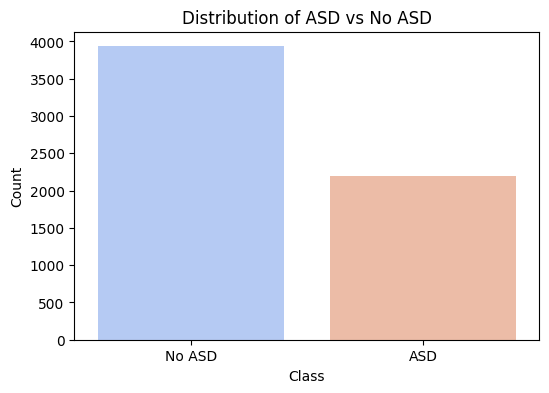


 ----------------------- 
 Class
No ASD    3933
ASD       2197
Name: count, dtype: int64


In [77]:
plt.figure(figsize=(6, 4))
sns.countplot(data=combined_df, x='Class', palette='coolwarm')
plt.title("Distribution of ASD vs No ASD")
plt.xlabel("Class")
plt.ylabel('Count')
plt.show()

print('\n ----------------------- \n', combined_df['Class'].value_counts())

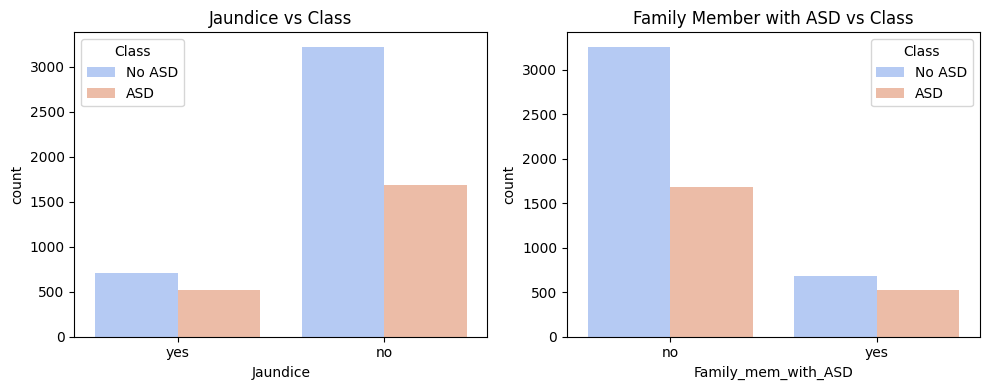

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=combined_df, x='Jaundice', hue='Class', ax=axes[0], palette='coolwarm')
axes[0].set_title('Jaundice vs Class')

sns.countplot(data=combined_df, x='Family_mem_with_ASD', hue='Class', ax=axes[1], palette='coolwarm')
axes[1].set_title('Family Member with ASD vs Class')

plt.tight_layout()
plt.show()

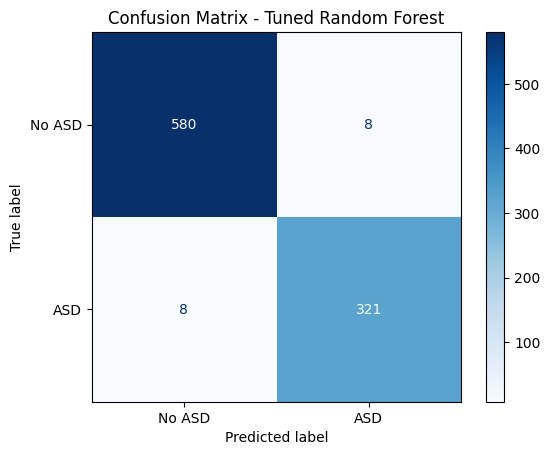

Validation Accuracy: 0.9825517993456925
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       588
           1       0.98      0.98      0.98       329

    accuracy                           0.98       917
   macro avg       0.98      0.98      0.98       917
weighted avg       0.98      0.98      0.98       917



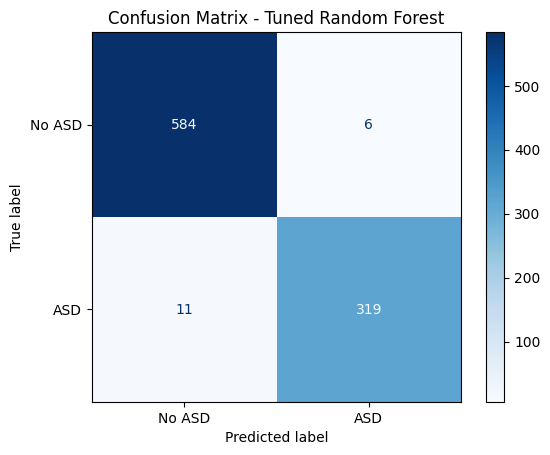

Test Accuracy: 0.9815217391304348
Test Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       590
           1       0.98      0.97      0.97       330

    accuracy                           0.98       920
   macro avg       0.98      0.98      0.98       920
weighted avg       0.98      0.98      0.98       920



In [79]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

# Encode target variable
df_encoded = combined_df.copy()
df_encoded['Class'] = df_encoded['Class'].map({'No ASD': 0, 'ASD': 1})

X = df_encoded.drop('Class', axis=1)
y = df_encoded['Class']

binary_cols = ['Sex', 'Jaundice', 'Family_mem_with_ASD']
numeric_cols = [col for col in X.columns if col not in binary_cols]


# ---- Train/Validation/Test Split ----
# Step 1: Split into train+val (85%) and test (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42,  #stratify ensures that the proportion of classes in y is the same in both train+val and test sets
)

# Step 2: Split train+val into train and validation 80% = 60% train, 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, stratify=y_train_val, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('bin', OneHotEncoder(), binary_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# ---- Build Pipline ----
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'  #Improves minority-class recall without modifying data
    ))
])


pipeline.fit(X_train, y_train)


y_val_pred = pipeline.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

cm = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(cm, display_labels=['No ASD', 'ASD']).plot(cmap='Blues')
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

print("Validation Accuracy:", val_acc)
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))


y_test_pred = pipeline.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['No ASD', 'ASD']).plot(cmap='Blues')
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

print("Test Accuracy:", test_acc)
print("Test Classification Report:\n", classification_report(y_test, y_test_pred))




# joblib.dump(pipeline, r"C:\Users\dell\Documents\asd_RF_pipeline.pkl")
# print("\n💾 Model saved as 'asd_RF_pipeline.pkl'")



**KNN**

Best Hyperparameters: {'model__n_neighbors': 17, 'model__p': 1, 'model__weights': 'distance'}


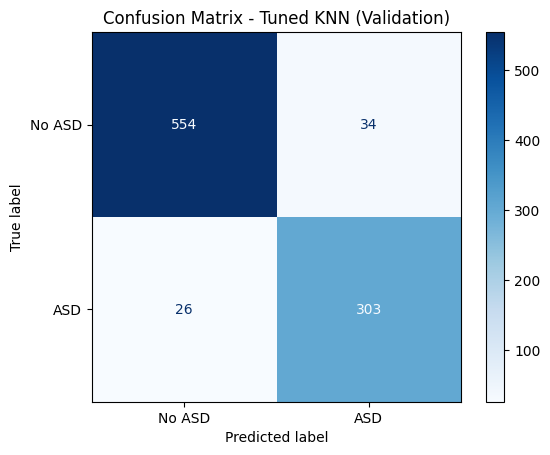

Validation Accuracy: 0.9345692475463467
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95       588
           1       0.90      0.92      0.91       329

    accuracy                           0.93       917
   macro avg       0.93      0.93      0.93       917
weighted avg       0.94      0.93      0.93       917



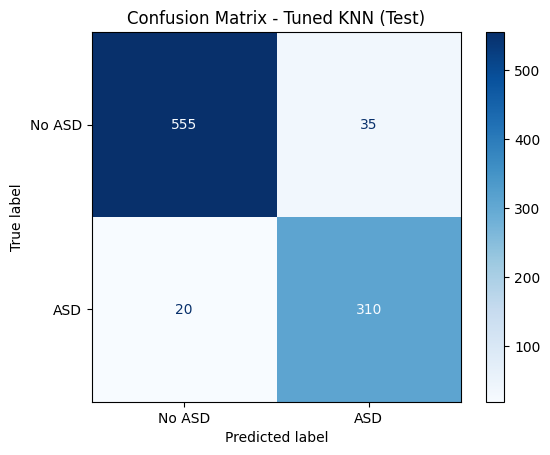

Test Accuracy: 0.9402173913043478
Test Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95       590
           1       0.90      0.94      0.92       330

    accuracy                           0.94       920
   macro avg       0.93      0.94      0.94       920
weighted avg       0.94      0.94      0.94       920



In [80]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as ImbPipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Encode target variable
df_encoded = combined_df.copy()
df_encoded['Class'] = df_encoded['Class'].map({'No ASD': 0, 'ASD': 1})

X = df_encoded.drop('Class', axis=1)
y = df_encoded['Class']

binary_cols = ['Sex', 'Jaundice', 'Family_mem_with_ASD']
numeric_cols = [col for col in X.columns if col not in binary_cols]

# ---- Train/Validation/Test Split ----
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, stratify=y_train_val, random_state=42
)

# ---- Preprocessor ----
preprocessor = ColumnTransformer(
    transformers=[
        ('bin', OneHotEncoder(), binary_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# ---- KNN Pipeline ----
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

# ---- Hyperparameter Grid ----
param_grid = {
    'model__n_neighbors': list(range(3, 21, 2)),  # odd numbers from 3 to 19
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

# ---- Validation Metrics ----
y_val_pred = grid_search.predict(X_val)
knn_acc = accuracy_score(y_val, y_val_pred)
cm = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(cm, display_labels=['No ASD', 'ASD']).plot(cmap='Blues')
plt.title("Confusion Matrix - Tuned KNN (Validation)")
plt.show()

print("Validation Accuracy:", knn_acc)
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))

# ---- Test Metrics ----
y_test_pred = grid_search.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['No ASD', 'ASD']).plot(cmap='Blues')
plt.title("Confusion Matrix - Tuned KNN (Test)")
plt.show()

print("Test Accuracy:", test_acc)
print("Test Classification Report:\n", classification_report(y_test, y_test_pred))


Best Hyperparameters: {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}


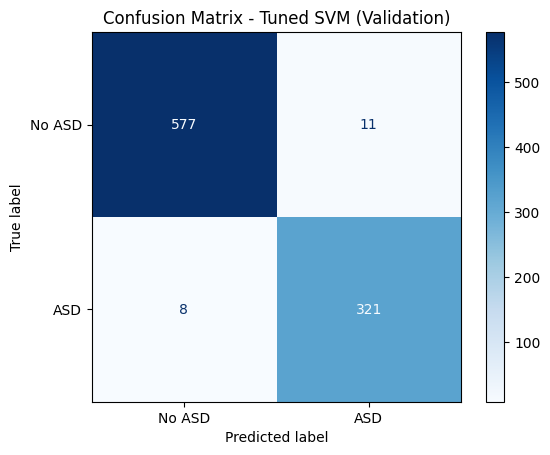

Validation Accuracy: 0.9792802617230099
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       588
           1       0.97      0.98      0.97       329

    accuracy                           0.98       917
   macro avg       0.98      0.98      0.98       917
weighted avg       0.98      0.98      0.98       917



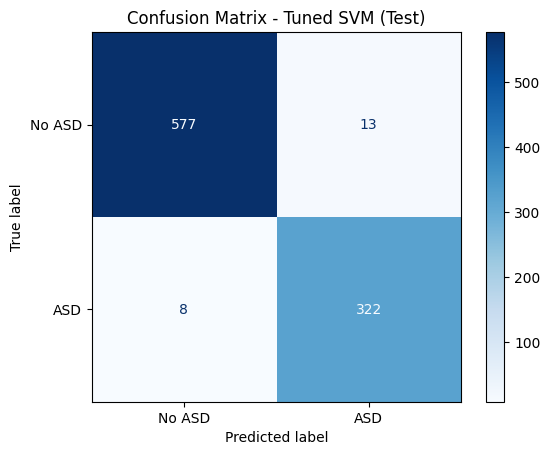

Test Accuracy: 0.9771739130434782
Test Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       590
           1       0.96      0.98      0.97       330

    accuracy                           0.98       920
   macro avg       0.97      0.98      0.98       920
weighted avg       0.98      0.98      0.98       920



In [81]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as ImbPipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Encode target variable
df_encoded = combined_df.copy()
df_encoded['Class'] = df_encoded['Class'].map({'No ASD': 0, 'ASD': 1})

X = df_encoded.drop('Class', axis=1)
y = df_encoded['Class']

binary_cols = ['Sex', 'Jaundice', 'Family_mem_with_ASD']
numeric_cols = [col for col in X.columns if col not in binary_cols]

# ---- Train/Validation/Test Split ----
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, stratify=y_train_val, random_state=42
)

# ---- Preprocessor ----
preprocessor = ColumnTransformer(
    transformers=[
        ('bin', OneHotEncoder(), binary_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# ---- SVM Pipeline ----
pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC())
])

# ---- Hyperparameter Grid ----
param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf', 'poly'],
    'model__gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)

# ---- Validation Metrics ----
y_val_pred = grid_search.predict(X_val)
svm_acc = accuracy_score(y_val, y_val_pred)
cm = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(cm, display_labels=['No ASD', 'ASD']).plot(cmap='Blues')
plt.title("Confusion Matrix - Tuned SVM (Validation)")
plt.show()

print("Validation Accuracy:", svm_acc)
print("Validation Classification Report:\n", classification_report(y_val, y_val_pred))

# ---- Test Metrics ----
y_test_pred = grid_search.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['No ASD', 'ASD']).plot(cmap='Blues')
plt.title("Confusion Matrix - Tuned SVM (Test)")
plt.show()

print("Test Accuracy:", test_acc)
print("Test Classification Report:\n", classification_report(y_test, y_test_pred))


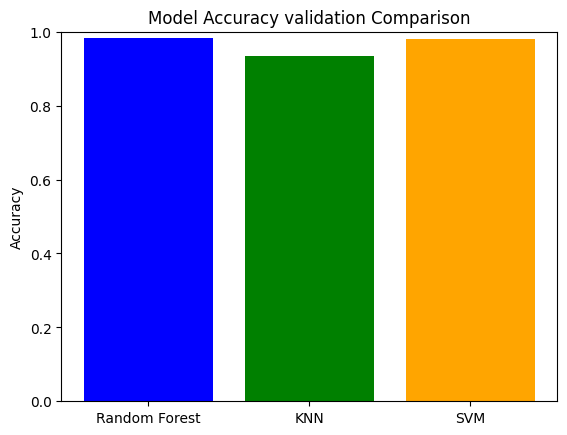

In [82]:
models = ["Random Forest", "KNN", "SVM"]

acss = [val_acc, knn_acc, svm_acc]

plt.bar(models, acss, color=['blue', 'green', 'orange'])
plt.title("Model Accuracy validation Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()